# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [58]:
df = pd.read_csv("../data/states_edu.csv")
df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [42]:
print(df["AVG_MATH_8_SCORE"].unique())

[252. 265. 256. 261. 272. 274. 263. 235. 260. 259. 257. 275. 270. 283.
 262. 250. 279. 273. 267. 282. 246. 271. 278. 266. 258. 268. 264. 269.
 281. 277. 287. 254. 285. 280. 276. 284. 243. 291. 286. 245. 292. 290.
 248. 298. 288. 289. 299. 294. 293. 295. 301. 296. 297. 253. 231. 255.
 251.]


<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: *Grade 8 Math*

In [69]:
#Dropping the NaN values from our wanted data
df.dropna(subset=['AVG_MATH_8_SCORE'], inplace=True)

In [35]:
# @@@ 1
print(df["YEAR"])
print("Our data contains the years from 1992 to 2019, however the years without NaN values are from 2003 to 2015, and even in these years there are gaps in the data depending on thet states we sample")

0       1992
2       1992
3       1992
4       1992
5       1992
        ... 
1710    2019
1711    2019
1712    2019
1713    2019
1714    2019
Name: YEAR, Length: 602, dtype: int64
Our data contains the years from 1992 to 2019, however the years without NaN values are from 2003 to 2015, and even in these years there are gaps in the data depending on thet states we sample


How many years of data are logged in our dataset? 

Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [36]:
# @@@ 2
mich_scores = df[df["STATE"]=="MICHIGAN"]["AVG_MATH_8_SCORE"].mean()
ohio_scores = df[df["STATE"]=="OHIO"]["AVG_MATH_8_SCORE"].mean()
print(mich_scores, ohio_scores)
if(mich_scores>ohio_scores):
    print("MICHIGAN")
else:
    print("OHIO")

276.1666666666667 282.25
OHIO


Find the average for your chosen test across all states in 2019

In [50]:
# @@@ 3
print(df[df["YEAR"]==2019]["AVG_MATH_8_SCORE"].mean())

281.2641509433962


For each state, find a maximum value for your chosen test score

In [57]:
# @@@ 4
print((df["STATE"].unique()))
df.groupby("STATE")["AVG_MATH_8_SCORE"].max()

['ALABAMA' 'ARIZONA' 'ARKANSAS' 'CALIFORNIA' 'COLORADO' 'CONNECTICUT'
 'DELAWARE' 'DISTRICT_OF_COLUMBIA' 'FLORIDA' 'GEORGIA' 'HAWAII' 'IDAHO'
 'INDIANA' 'IOWA' 'KENTUCKY' 'LOUISIANA' 'MAINE' 'MARYLAND'
 'MASSACHUSETTS' 'MICHIGAN' 'MINNESOTA' 'MISSISSIPPI' 'MISSOURI'
 'NEBRASKA' 'NEW_HAMPSHIRE' 'NEW_JERSEY' 'NEW_MEXICO' 'NEW_YORK'
 'NORTH_CAROLINA' 'NORTH_DAKOTA' 'OHIO' 'OKLAHOMA' 'PENNSYLVANIA'
 'RHODE_ISLAND' 'SOUTH_CAROLINA' 'TENNESSEE' 'TEXAS' 'UTAH' 'VIRGINIA'
 'WEST_VIRGINIA' 'WISCONSIN' 'WYOMING' 'ILLINOIS' 'KANSAS' 'MONTANA'
 'NEVADA' 'OREGON' 'VERMONT' 'ALASKA' 'SOUTH_DAKOTA' 'WASHINGTON'
 'NATIONAL' 'DODEA']


STATE
ALABAMA                 269.0
ALASKA                  283.0
ARIZONA                 283.0
ARKANSAS                279.0
CALIFORNIA              277.0
COLORADO                292.0
CONNECTICUT             289.0
DELAWARE                284.0
DISTRICT_OF_COLUMBIA    269.0
DODEA                   293.0
FLORIDA                 281.0
GEORGIA                 281.0
HAWAII                  281.0
IDAHO                   287.0
ILLINOIS                285.0
INDIANA                 288.0
IOWA                    286.0
KANSAS                  290.0
KENTUCKY                282.0
LOUISIANA               273.0
MAINE                   289.0
MARYLAND                288.0
MASSACHUSETTS           301.0
MICHIGAN                280.0
MINNESOTA               295.0
MISSISSIPPI             274.0
MISSOURI                286.0
MONTANA                 293.0
NATIONAL                285.0
NEBRASKA                288.0
NEVADA                  278.0
NEW_HAMPSHIRE           296.0
NEW_JERSEY              296.0
NEW_

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [60]:
# @@@ 5
df['AVG_8_MATH_SCORE_PER_STATE_REV'] = df['AVG_MATH_8_SCORE'] / df['STATE_REVENUE']
df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE,AVG_8_MATH_SCORE_PER_STATE_REV
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN,0.000152
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN,0.000193
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN,0.000267
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN,0.000016


Feature engineering justification: **<BRIEFLY DESCRIBE WHY YOU MADE THE CHANGES THAT YOU DID\>**

I chose to make an additional column showing how state revenue affected the average 8th grade math score because education usually depends on how rich the area you are from is, and having a column that showed a rough ratio between revenue and math scores was a way to represent that.

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

Text(0, 0.5, '8th Grade Reading Score')

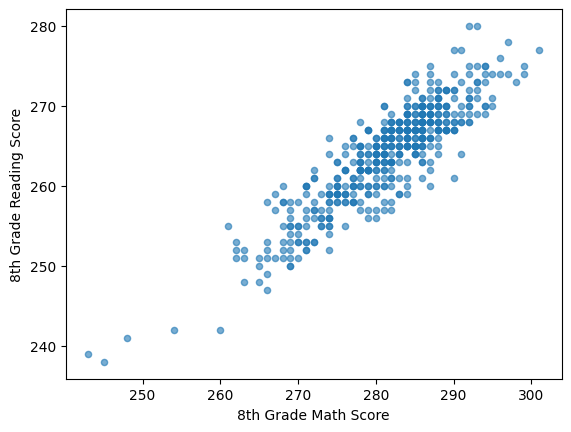

In [67]:
# @@@ 6
df.plot.scatter(x='AVG_MATH_8_SCORE', y='AVG_READING_8_SCORE', alpha=0.6)
plt.xlabel('8th Grade Math Score')
plt.ylabel('8th Grade Reading Score')
#This graph shows a clear positive correlation between math and reading scores among 8th graders,revealing that when 8th graders are
#Proficient at one subject, they tend to excel in the other as well

**Math Score Vs Reading Score (8th Grade)**

**Visualization 2**

Text(0, 0.5, 'State Revenue')

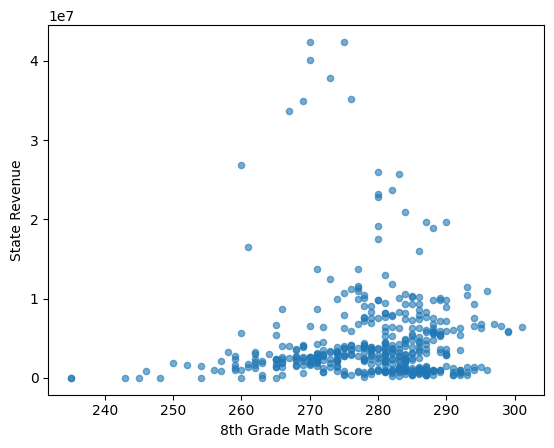

In [66]:
# @@@ 7
df.plot.scatter(x='AVG_MATH_8_SCORE', y='STATE_REVENUE', alpha=0.6)
plt.xlabel('8th Grade Math Score')
plt.ylabel('State Revenue')
#This graph does not have show a strong correlation between state revenue and math scores, meaning my earlier prediction of 
#state revenue being important to scores on test may have been wrong. Further testing is necessary

**Math Score Vs State Revenue**

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [68]:
from sklearn.model_selection import train_test_split

In [89]:
# @@@ 8
X = df[['AVG_MATH_8_SCORE', 'STATE_REVENUE']].dropna()
y = df.loc[X.index]['AVG_READING_8_SCORE'].dropna()
X = X.loc[y.index]

In [90]:
# @@@ 9 
#Splitting up the test and train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [91]:
# @@@ 10
# import your sklearn class here
from sklearn.linear_model import LinearRegression

In [92]:
# @@@ 11
# create your model here
model = LinearRegression()

In [93]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [94]:
y_pred = model.predict(X_test)

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [101]:
# @@@ 12
# mean error
print("mean error")
print(np.mean(model.predict(X_test)-y_test))
# rmse
print("rmse")
print(np.mean((model.predict(X_test)-y_test)**2)**0.5)

mean error
-1.0560461035017636
rmse
2.6935725944376117


We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

Text(0.5, 1.0, 'Model Behavior On Training Set')

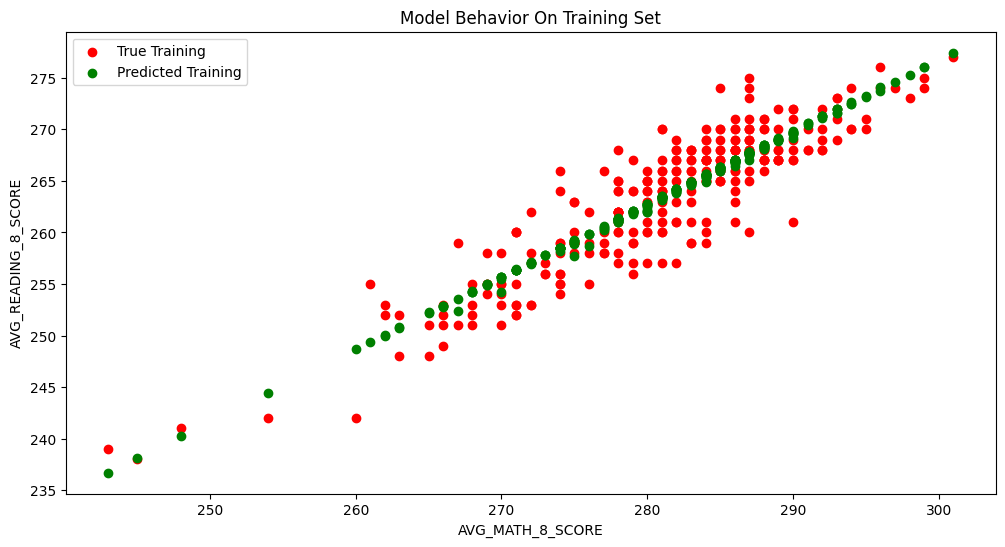

In [103]:
# @@@ 13

col_name = 'AVG_MATH_8_SCORE'


f = plt.figure(figsize=(12,6))
plt.scatter(X_train[col_name], y_train, color = "red")
plt.scatter(X_train[col_name], model.predict(X_train), color = "green")

plt.legend(['True Training','Predicted Training'])
plt.xlabel(col_name)
plt.ylabel('AVG_READING_8_SCORE')
plt.title("Model Behavior On Training Set")

Text(0.5, 1.0, 'Model Behavior on Testing Set')

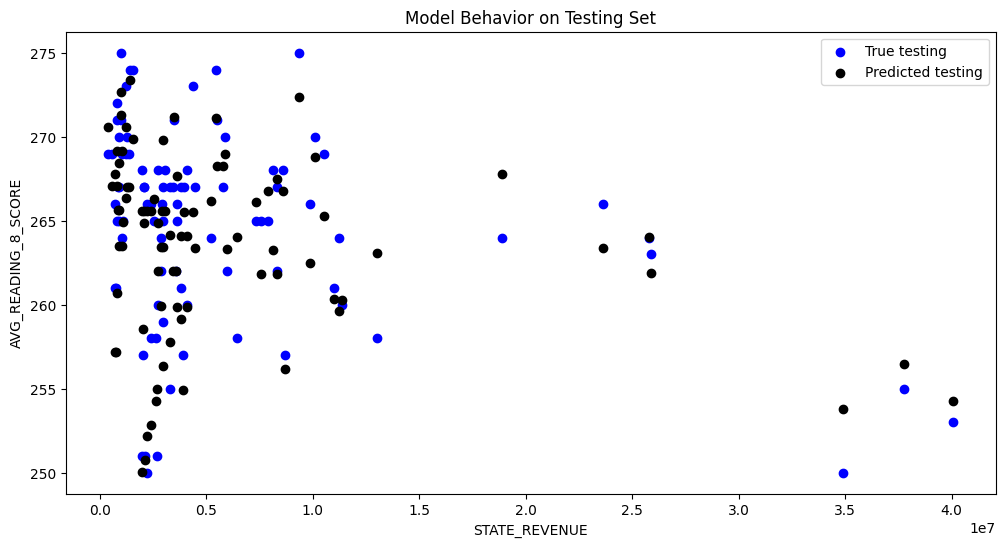

In [105]:
# @@@ 14


col_name = 'STATE_REVENUE'


f = plt.figure(figsize=(12,6))
plt.scatter(X_test[col_name], y_test, color = "blue")
plt.scatter(X_test[col_name], model.predict(X_test), color = "black")

plt.legend(['True testing','Predicted testing'])
plt.xlabel(col_name)
plt.ylabel('AVG_READING_8_SCORE')
plt.title("Model Behavior on Testing Set")